In [1]:
import os

SRC_DIR = "/kaggle/input/datasets/swetha344/pyg-210-cu128-wheels"
DST_DIR = "/kaggle/working/fixed_wheels"

os.makedirs(DST_DIR, exist_ok=True)

rename_map = {
    "torch_scatter-2.1.2pt210cu128-cp312-cp312-linux_x86_64.whl": "torch_scatter-2.1.2+pt210cu128-cp312-cp312-linux_x86_64.whl",
    "torch_cluster-1.6.3pt210cu128-cp312-cp312-linux_x86_64.whl": "torch_cluster-1.6.3+pt210cu128-cp312-cp312-linux_x86_64.whl",
    "pyg_lib-0.4.0pt210cu128-cp312-cp312-linux_x86_64.whl": "pyg_lib-0.4.0+pt210cu128-cp312-cp312-linux_x86_64.whl",
    "torch_geometric-2.7.0-py3-none-any.whl": "torch_geometric-2.7.0-py3-none-any.whl",
    "ogb-1.3.6-py3-none-any.whl": "ogb-1.3.6-py3-none-any.whl"
}

for old_name, new_name in rename_map.items():
    src = os.path.join(SRC_DIR, old_name)
    dst = os.path.join(DST_DIR, new_name)
    if os.path.exists(src) and not os.path.exists(dst):
        os.symlink(src, dst)

!pip install --no-index --no-deps --force-reinstall /kaggle/working/fixed_wheels/*.whl

Processing ./fixed_wheels/ogb-1.3.6-py3-none-any.whl
Processing ./fixed_wheels/torch_cluster-1.6.3+pt210cu128-cp312-cp312-linux_x86_64.whl
Processing ./fixed_wheels/torch_geometric-2.7.0-py3-none-any.whl
Processing ./fixed_wheels/torch_scatter-2.1.2+pt210cu128-cp312-cp312-linux_x86_64.whl


In [2]:
import os
os.environ["TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD"] = "1"

In [3]:
import torch
import torch_geometric

from torch_geometric.data.data import DataEdgeAttr
from torch_geometric.data.storage import NodeStorage, EdgeStorage, GlobalStorage

torch.serialization.add_safe_globals([
    DataEdgeAttr, 
    NodeStorage, 
    EdgeStorage, 
    GlobalStorage,
    torch_geometric.data.Data
])

from ogb.nodeproppred import PygNodePropPredDataset
import torch_geometric.transforms as T

with torch.serialization.safe_globals([DataEdgeAttr, NodeStorage, EdgeStorage]):
    dataset = PygNodePropPredDataset(name='ogbn-arxiv', root='dataset/', transform=T.ToUndirected())

Downloaded 0.08 GB: 100%|██████████| 81/81 [00:02<00:00, 34.21it/s]
Processing...


Extracting dataset/arxiv.zip
Loading necessary files...
This might take a while.
Processing graphs...


100%|██████████| 1/1 [00:00<00:00, 8422.30it/s]


Converting graphs into PyG objects...


100%|██████████| 1/1 [00:00<00:00, 367.28it/s]

Saving...



Done!
/usr/local/lib/python3.12/dist-packages/ogb/nodeproppred/dataset_pyg.py:69: UserWarning: Environment variable TORCH_FORCE_NO_WEIGHTS_ONLY_LOAD detected, since the`weights_only` argument was not explicitly passed to `torch.load`, forcing weights_only=False.
  self.data, self.slices = torch.load(self.processed_paths[0])


In [4]:
# 1. Basic Dataset Info
print(f"Number of graphs: {len(dataset)}")
print(f"Number of classes: {dataset.num_classes}")
print(f"Number of node features: {dataset.num_node_features}")

# 2. Get the actual Data object
data = dataset[0]

# 3. View Graph Structure
print("\n--- Graph Structure ---")
print(f"Number of nodes: {data.num_nodes}")
print(f"Number of edges: {data.num_edges}")
print(f"Is undirected: {data.is_undirected()}")
print(f"Has isolated nodes: {data.has_isolated_nodes()}")
print(f"Has self-loops: {data.has_self_loops()}")

# 4. Print one Node's Features
# Nodes are indexed. Let's look at node 0.
print("\n--- Node 0 Inspection ---")
print(f"Features (first 5 values): {data.x[0][:5]}")
print(f"Label: {data.y[0].item()}")

# 5. Inspect the Edge Index
# This is a [2, num_edges] tensor representing (source, target)
print("\n--- Edge Index ---")
print(data.edge_index)

Number of graphs: 1
Number of classes: 40
Number of node features: 128

--- Graph Structure ---
Number of nodes: 169343
Number of edges: 2315598
Is undirected: True
Has isolated nodes: False
Has self-loops: False

--- Node 0 Inspection ---
Features (first 5 values): tensor([-0.0579, -0.0525, -0.0726, -0.0266,  0.1304])
Label: 4

--- Edge Index ---
tensor([[     0,      0,      0,  ..., 169341, 169342, 169342],
        [   411,    640,   1162,  ..., 163274,  27824, 158981]])


In [5]:
split_idx = dataset.get_idx_split()
train_idx, valid_idx, test_idx = split_idx["train"], split_idx["valid"], split_idx["test"]

print(f"\nTraining nodes: {len(train_idx)}")
print(f"Validation nodes: {len(valid_idx)}")
print(f"Test nodes: {len(test_idx)}")

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)


Training nodes: 90941
Validation nodes: 29799
Test nodes: 48603


In [6]:
import torch.nn.functional as F
from torch_geometric.nn import GCNConv
import torch.nn as nn

class GCN(torch.nn.Module):
    def __init__(self, in_channels, hidden_channels, out_channels, num_layers, dropout):
        super(GCN, self).__init__()
        
        self.convs = torch.nn.ModuleList()
        self.bns = torch.nn.ModuleList()
        
        # First layer
        self.convs.append(GCNConv(in_channels, hidden_channels))
        self.bns.append(nn.BatchNorm1d(hidden_channels))
        
        # Hidden layers
        for _ in range(num_layers - 2):
            self.convs.append(GCNConv(hidden_channels, hidden_channels))
            self.bns.append(nn.BatchNorm1d(hidden_channels))
            
        # Output layer
        self.convs.append(GCNConv(hidden_channels, out_channels))
        
        self.dropout = dropout

    def forward(self, x, edge_index):
        for i in range(len(self.convs) - 1):
            x = self.convs[i](x, edge_index)
            x = self.bns[i](x)
            x = F.relu(x)
            x = F.dropout(x, p=self.dropout, training=self.training)
            
        x = self.convs[-1](x, edge_index)
        return x # Return logits (LogSoftmax usually handled by loss function)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
criterion = torch.nn.CrossEntropyLoss()

In [7]:
import torch
import numpy as np

# Configuration
num_runs = 10
epochs = 500
all_test_results = []
global_best_test_acc = 0.0
global_save_path = 'ablation_identity_best_model.pt'

# --- ABLATION STEP: CREATE IDENTITY EDGE INDEX ---
# We create an edge_index where every node only connects to itself.
# This effectively makes the GCN layer act as a linear transformation 
# applied to each node independently.
node_indices = torch.arange(data.num_nodes, device=device)
identity_edge_index = torch.stack([node_indices, node_indices], dim=0).to(device)
# --------------------------------------------------

for run in range(num_runs):
    seed = run
    torch.manual_seed(seed)
    torch.cuda.manual_seed_all(seed)
    np.random.seed(seed)
    
    print(f"\n>>> Starting Run {run+1}/{num_runs} (Identity Ablation - Seed: {seed})")
    
    model = GCN(
        in_channels=dataset.num_node_features, 
        hidden_channels=256, 
        out_channels=dataset.num_classes, 
        num_layers=3, 
        dropout=0.5
    ).to(device)

    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    criterion = torch.nn.CrossEntropyLoss() # Ensure criterion is defined
    
    best_run_val_acc = 0
    best_run_test_acc = 0

    for epoch in range(1, epochs + 1):
        model.train()
        optimizer.zero_grad()
        
        # Use identity_edge_index instead of data.edge_index
        out = model(data.x, identity_edge_index)
        
        loss = criterion(out[train_idx], data.y[train_idx].squeeze())
        loss.backward()
        optimizer.step()

        if epoch % 50 == 0:
            model.eval()
            with torch.no_grad():
                # Use identity_edge_index here as well
                logits = model(data.x, identity_edge_index)
                y_pred = logits.argmax(dim=-1, keepdim=True)
                
                val_acc = (y_pred[valid_idx] == data.y[valid_idx]).sum().item() / valid_idx.size(0)
                test_acc = (y_pred[test_idx] == data.y[test_idx]).sum().item() / test_idx.size(0)
                
                if val_acc > best_run_val_acc:
                    best_run_val_acc = val_acc
                    best_run_test_acc = test_acc

                    if test_acc > global_best_test_acc:
                        global_best_test_acc = test_acc
                        torch.save(model.state_dict(), global_save_path)

    all_test_results.append(best_run_test_acc)
    print(f"Run {run+1} Finished. Best Test Acc (Identity): {best_run_test_acc:.4f}")

mean_acc = np.mean(all_test_results)
std_acc = np.std(all_test_results)
print("\n" + "="*30)
print(f"ABLATION (IDENTITY) METRICS OVER {num_runs} RUNS")
print(f"Mean Test Accuracy: {mean_acc:.4f} ± {std_acc:.4f}")
print("="*30)


>>> Starting Run 1/10 (Identity Ablation - Seed: 0)
Run 1 Finished. Best Test Acc (Identity): 0.5558

>>> Starting Run 2/10 (Identity Ablation - Seed: 1)
Run 2 Finished. Best Test Acc (Identity): 0.5591

>>> Starting Run 3/10 (Identity Ablation - Seed: 2)
Run 3 Finished. Best Test Acc (Identity): 0.5577

>>> Starting Run 4/10 (Identity Ablation - Seed: 3)
Run 4 Finished. Best Test Acc (Identity): 0.5576

>>> Starting Run 5/10 (Identity Ablation - Seed: 4)
Run 5 Finished. Best Test Acc (Identity): 0.5543

>>> Starting Run 6/10 (Identity Ablation - Seed: 5)
Run 6 Finished. Best Test Acc (Identity): 0.5565

>>> Starting Run 7/10 (Identity Ablation - Seed: 6)
Run 7 Finished. Best Test Acc (Identity): 0.5556

>>> Starting Run 8/10 (Identity Ablation - Seed: 7)
Run 8 Finished. Best Test Acc (Identity): 0.5546

>>> Starting Run 9/10 (Identity Ablation - Seed: 8)
Run 9 Finished. Best Test Acc (Identity): 0.5526

>>> Starting Run 10/10 (Identity Ablation - Seed: 9)
Run 10 Finished. Best Test A

/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/manifold/_t_sne.py:1164: FutureWarning: 'n_iter' was renamed to 'max_iter' in version 1.5 and will be removed in 1.7.
  warnings.warn(


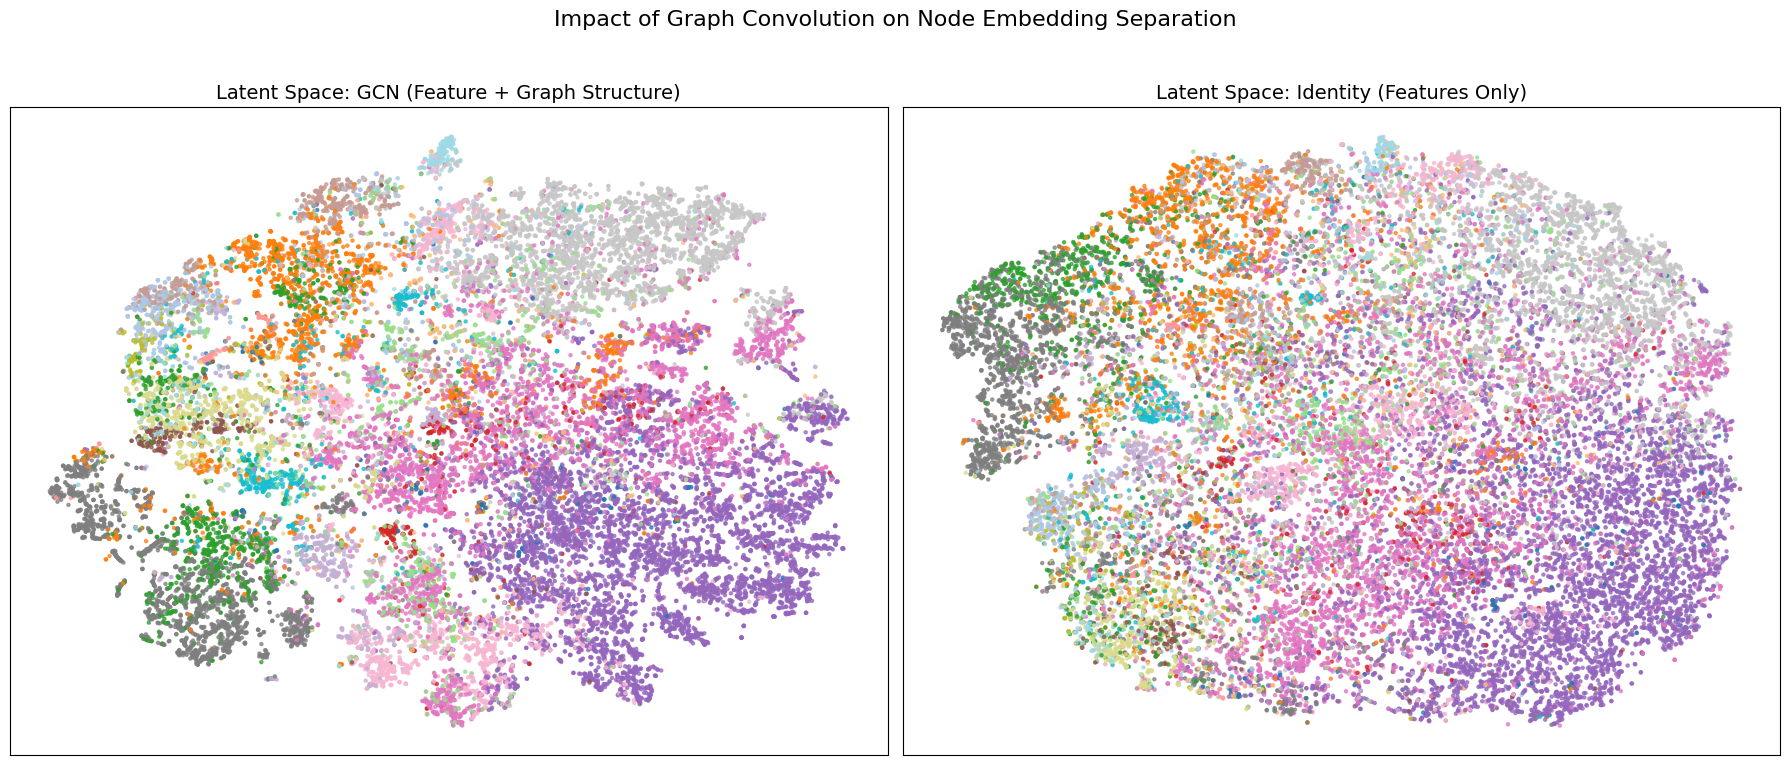

In [11]:
import matplotlib.pyplot as plt
from sklearn.manifold import TSNE

# 1. Setup and Train
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
data = data.to(device)
node_indices = torch.arange(data.num_nodes, device=device)
identity_edge_index = torch.stack([node_indices, node_indices], dim=0)

def train_and_get_embeddings(edge_index_to_use):
    model = GCN(
        in_channels=dataset.num_node_features, 
        hidden_channels=256, 
        out_channels=dataset.num_classes, 
        num_layers=3, 
        dropout=0.5
    ).to(device)
    
    optimizer = torch.optim.Adam(model.parameters(), lr=0.01)
    
    for epoch in range(1, 201):
        model.train()
        optimizer.zero_grad()
        out = model(data.x, edge_index_to_use)
        loss = F.cross_entropy(out[train_idx], data.y[train_idx].squeeze())
        loss.backward()
        optimizer.step()
    
    model.eval()
    with torch.no_grad():
        # Get embeddings from the validation set
        logits = model(data.x, edge_index_to_use)
        val_embeddings = logits[valid_idx].cpu().numpy()
        val_labels = data.y[valid_idx].cpu().numpy().squeeze()
        
    return val_embeddings, val_labels

# 2. Generate Data
gcn_emb, gcn_y = train_and_get_embeddings(data.edge_index)
mlp_emb, mlp_y = train_and_get_embeddings(identity_edge_index)

# 3. Final Comparison Plot
def plot_pure_clusters(embeddings, labels, title, subplot_idx):
    # n_iter=1000 and perplexity=30 are usually good defaults for Arxiv
    tsne = TSNE(n_components=2, perplexity=30, n_iter=1000, random_state=42)
    z = tsne.fit_transform(embeddings)
    
    plt.subplot(1, 2, subplot_idx)
    # Using 'tab20' or 'jet' helps differentiate the 40 classes in ogbn-arxiv
    scatter = plt.scatter(z[:, 0], z[:, 1], s=5, c=labels, cmap="tab20", alpha=0.7)
    plt.title(title, fontsize=14)
    plt.xticks([]); plt.yticks([])

plt.figure(figsize=(18, 8))
plot_pure_clusters(gcn_emb, gcn_y, "Latent Space: GCN (Feature + Graph Structure)", 1)
plot_pure_clusters(mlp_emb, mlp_y, "Latent Space: Identity (Features Only)", 2)

plt.suptitle("Impact of Graph Convolution on Node Embedding Separation", fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()